In [ ]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import torch
from torch.distributions import MultivariateNormal
import pyro
import pyro.distributions as dist
from pyro.distributions import transforms as T

# Modules
from Data_generation.generate_gaussian_data import generate_gaussian_data
from Data_generation.generate_archimedean_data import generate_archimedean_data
from Data_generation.generate_non_gaussian_data import generate_non_gaussian_data

from sensitivity_model import sensitivity_analysis

from Visualization.plot_ace_curve import plot_ace_curve
from Visualization.plot_mean_std_ace_curve import plot_mean_std_ace_curve

In [ ]:
import torch
print(f"Is CUDA (GPU) available? : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Current Device: {torch.cuda.get_device_name(0)}")

## Gaussian

In [ ]:
# Data generation for Gaussian noise
true_alpha = -5.0
true_rho = 0.7
rho_assumptions = torch.linspace(-0.9, 0.9, 19)
T_data, Y_data = generate_gaussian_data(num_samples=1000,
                                        alpha=true_alpha,
                                        rho=true_rho)

In [ ]:
# Sensitivity Analysis for Gaussian noise
gauss_ace_results = sensitivity_analysis(T_data = T_data,
                                         Y_data = Y_data,
                                         learning_rate=3e-3,
                                         steps=1000,
                                         num_ace_samples=100000,
                                         rho_assumptions = rho_assumptions)


===== Training model for rho_assumption = -0.90 =====
Step 0 : loss = 101.78092193603516
--> For rho_assumption=-0.90, Estimated ACE: -2.5931

===== Training model for rho_assumption = -0.80 =====
Step 0 : loss = 54.859622955322266
--> For rho_assumption=-0.80, Estimated ACE: -3.2470

===== Training model for rho_assumption = -0.70 =====
Step 0 : loss = 39.4594612121582
--> For rho_assumption=-0.70, Estimated ACE: -3.5864

===== Training model for rho_assumption = -0.60 =====
Step 0 : loss = 31.939558029174805
--> For rho_assumption=-0.60, Estimated ACE: -3.7390

===== Training model for rho_assumption = -0.50 =====
Step 0 : loss = 27.586380004882812
--> For rho_assumption=-0.50, Estimated ACE: -3.8804

===== Training model for rho_assumption = -0.40 =====
Step 0 : loss = 24.837392807006836
--> For rho_assumption=-0.40, Estimated ACE: -4.0054

===== Training model for rho_assumption = -0.30 =====
Step 0 : loss = 23.03092384338379
--> For rho_assumption=-0.30, Estimated ACE: -4.0818

=

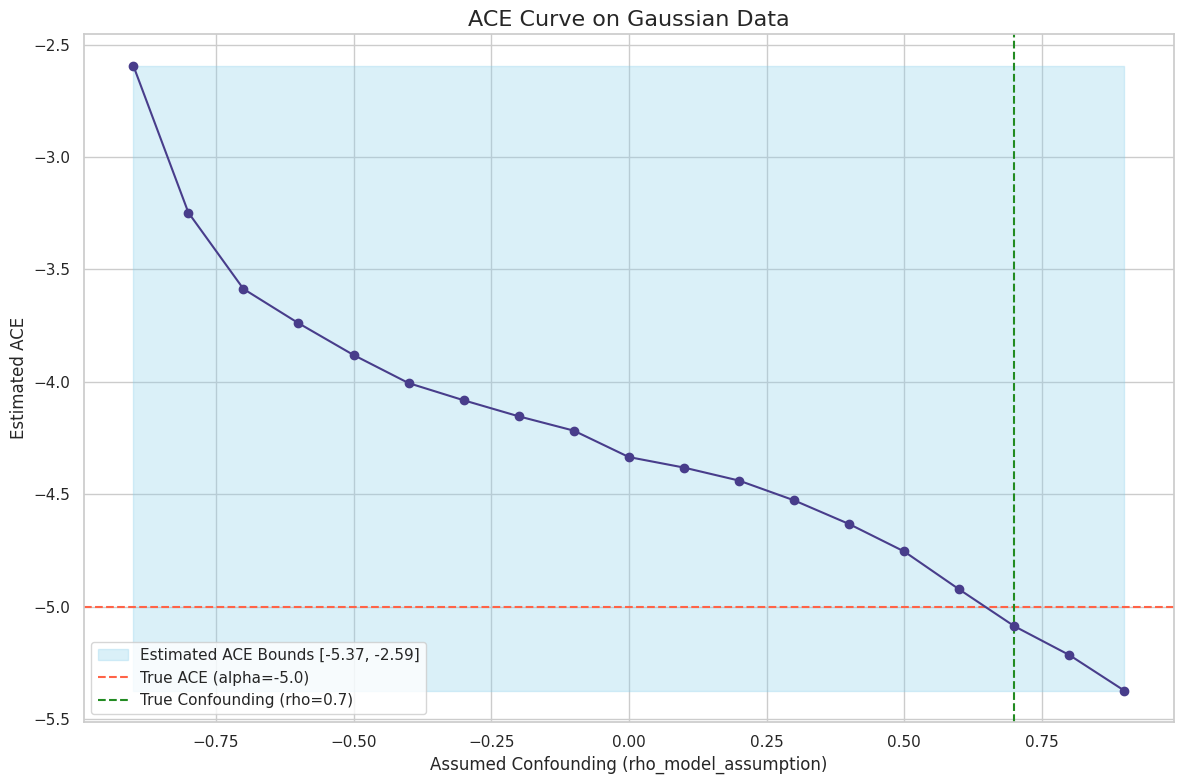

In [ ]:
# Plotting the ACE curve for Gaussian noise
plot_ace_curve(rho_assumptions = rho_assumptions,
                        ace_results = gauss_ace_results,
                        true_alpha = true_alpha,
                        true_rho = true_rho,
                        title = "ACE Curve on Gaussian Data")

### Experiment 1: Testing different true_alpha values for Gaussian

In [ ]:
number_of_runs = 20
true_alpha_values = [-2.0, 1.0, 2.0]
true_rho = 0.7
rho_assumptions = torch.linspace(-0.9, 0.9, 19)
all_results_gaussian_alpha = []

for i in range(number_of_runs):
    print(f"\n\n===== RUN {i+1} / {number_of_runs} =====")
    for true_alpha in true_alpha_values:
        T_data, Y_data = generate_gaussian_data(num_samples=1000,
                                                alpha=true_alpha,
                                                rho=true_rho)

        # Sensitivity Analysis for different true_alpha values
        ace_results = sensitivity_analysis(T_data = T_data,
                                        Y_data = Y_data,
                                        learning_rate=3e-3,
                                        steps=1000,
                                        num_ace_samples=100000,
                                        rho_assumptions = rho_assumptions)
        current_ace_values = ace_results if isinstance(ace_results, list) else ace_results.tolist()
        rho_vals = rho_assumptions.tolist()

        for idx, val in enumerate(current_ace_values):
            all_results_gaussian_alpha.append({
                'run_id': i,
                'true_alpha': true_alpha,
                "true_rho": true_rho,
                'assumed_rho': rho_vals[idx],
                'ace_value': val
            })
# Dataframe for Gaussian (Different alpha values)
df_gaussian_alpha = pd.DataFrame(all_results_gaussian_alpha)
df_gaussian_alpha.to_csv('df_gaussian_alpha.csv', index=False)

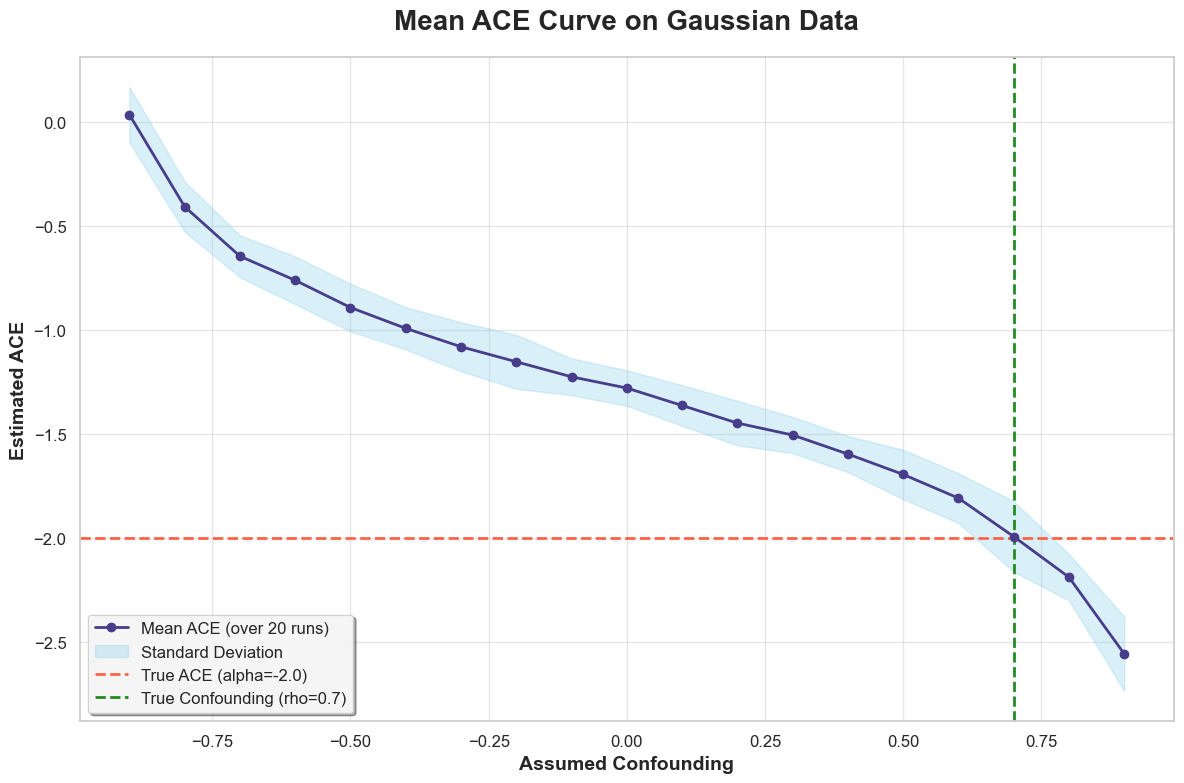

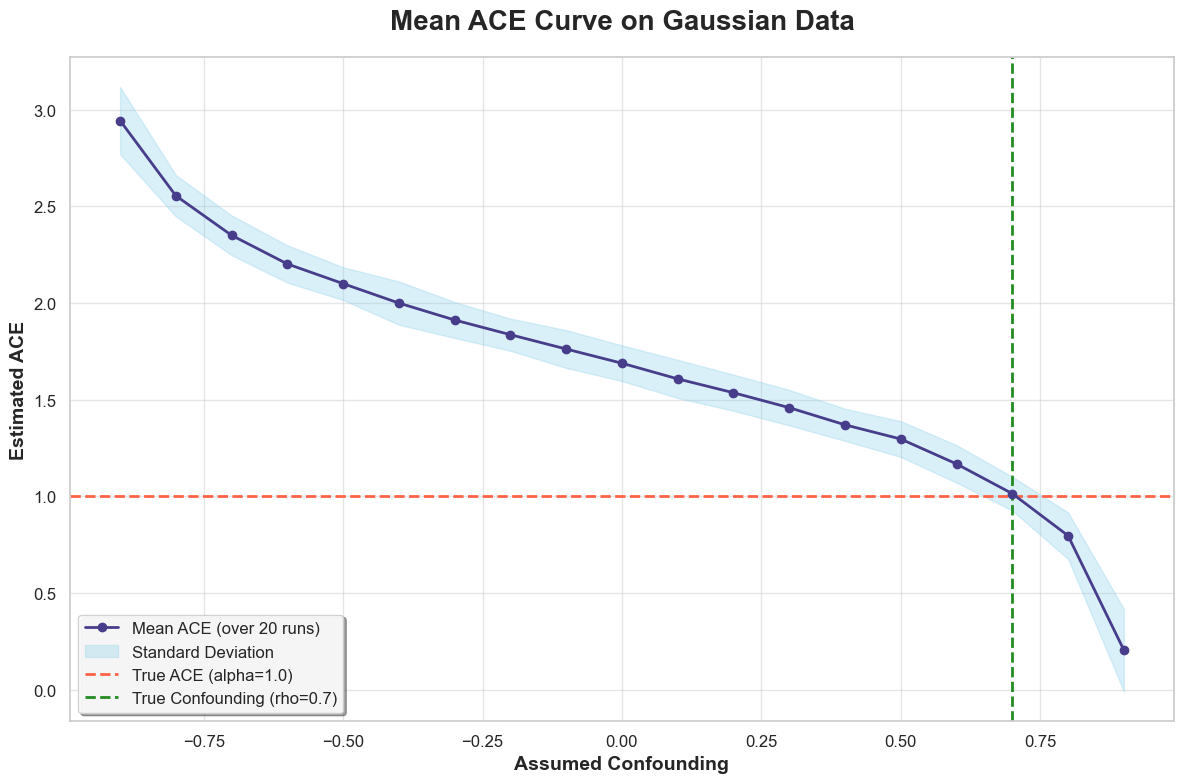

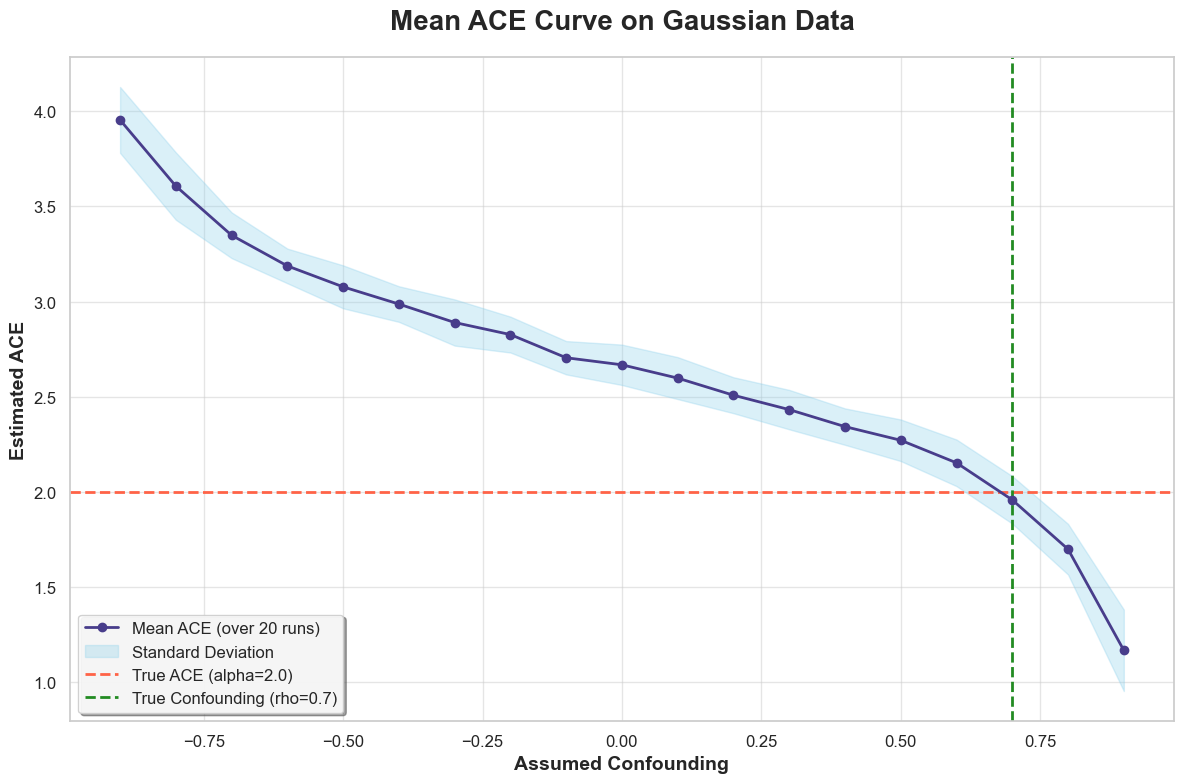

In [ ]:
df = pd.read_csv('df_gaussian_alpha.csv')

true_alpha_values = sorted(df['true_alpha'].unique())
true_rho = 0.7
rho_assumptions = torch.linspace(-0.9, 0.9, 19)
number_of_runs = df['run_id'].max()

for alpha in true_alpha_values:

    subset = df[df['true_alpha'] == alpha]

    ace_matrix = subset.pivot(index='run_id', columns='assumed_rho', values='ace_value')
    ace_means = ace_matrix.mean(axis=0).to_numpy()  # Mean ACE for each rho_assumption
    ace_stds = ace_matrix.std(axis=0).to_numpy()    # Std Dev of ACE for each rho_assumption

    plot_mean_std_ace_curve(rho_assumptions = rho_assumptions.numpy(),
                            ace_means = ace_means,
                            ace_stds = ace_stds,
                            true_alpha = alpha,
                            true_rho = true_rho,
                            num_runs = number_of_runs + 1,
                            title = f"Mean ACE Curve on Gaussian Data")

### Experiment 2: Testing different true_rho values For Gaussian

In [ ]:
number_of_runs = 20
true_alpha = 1.0
true_rho_values = [-0.7, 0, 0.7]
rho_assumptions = torch.linspace(-0.9, 0.9, 19)
all_results_gaussian_rho = []

for i in range(number_of_runs):
    print(f"\n\n===== RUN {i+1} / {number_of_runs} =====")
    for true_rho in true_rho_values:
        T_data, Y_data = generate_gaussian_data(num_samples=1000,
                                                alpha=true_alpha,
                                                rho=true_rho)

        # Sensitivity Analysis for different true_alpha values
        ace_results = sensitivity_analysis(T_data = T_data,
                                        Y_data = Y_data,
                                        learning_rate=3e-3,
                                        steps=1000,
                                        num_ace_samples=100000,
                                        rho_assumptions = rho_assumptions)
        current_ace_values = ace_results if isinstance(ace_results, list) else ace_results.tolist()
        rho_vals = rho_assumptions.tolist()

        for idx, val in enumerate(current_ace_values):
            all_results_gaussian_rho.append({
                'run_id': i,
                'true_alpha': true_alpha,
                'true_rho': true_rho,
                'assumed_rho': rho_vals[idx],
                'ace_value': val
            })
# Dataframe for Gaussian (Different rho values)
df_gaussian_rho = pd.DataFrame(all_results_gaussian_rho)
df_gaussian_rho.to_csv('df_gaussian_rho.csv', index=False)



===== RUN 1 / 20 =====

===== Training model for rho_assumption = -0.90 =====
Step 0 : loss = 41.415096282958984
--> For rho_assumption=-0.90, Estimated ACE: 1.4804

===== Training model for rho_assumption = -0.80 =====
Step 0 : loss = 27.96460723876953
--> For rho_assumption=-0.80, Estimated ACE: 1.1549

===== Training model for rho_assumption = -0.70 =====
Step 0 : loss = 55.47687530517578
--> For rho_assumption=-0.70, Estimated ACE: 1.0385

===== Training model for rho_assumption = -0.60 =====
Step 0 : loss = 11.193448066711426
--> For rho_assumption=-0.60, Estimated ACE: 0.8582

===== Training model for rho_assumption = -0.50 =====
Step 0 : loss = 26.662628173828125
--> For rho_assumption=-0.50, Estimated ACE: 0.7478

===== Training model for rho_assumption = -0.40 =====
Step 0 : loss = 4.568333625793457
--> For rho_assumption=-0.40, Estimated ACE: 0.6429

===== Training model for rho_assumption = -0.30 =====
Step 0 : loss = 25.409223556518555
--> For rho_assumption=-0.30, Estima

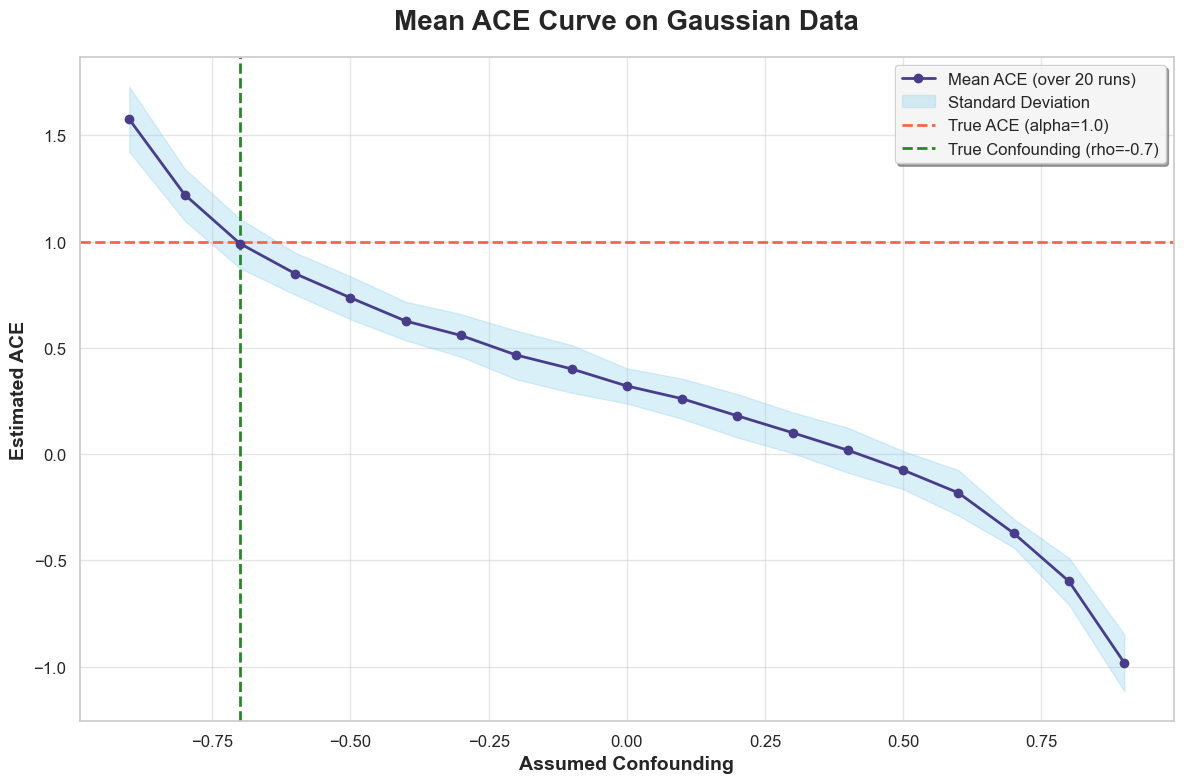

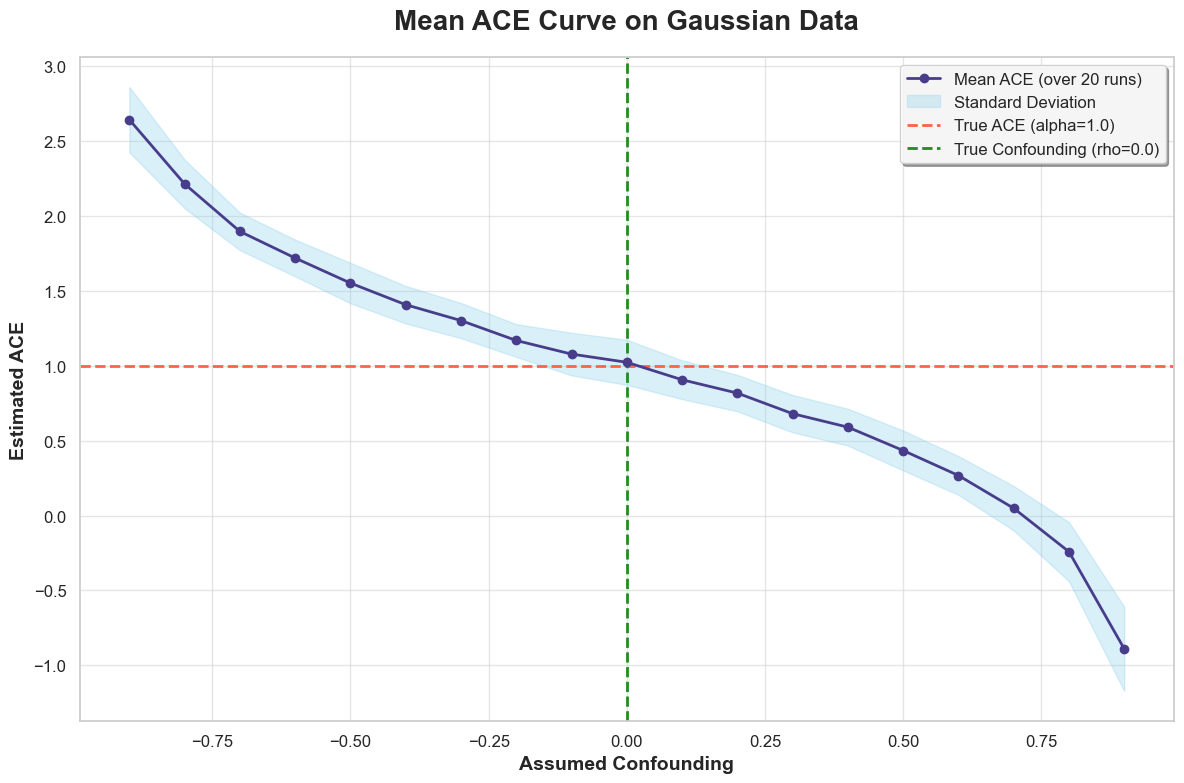

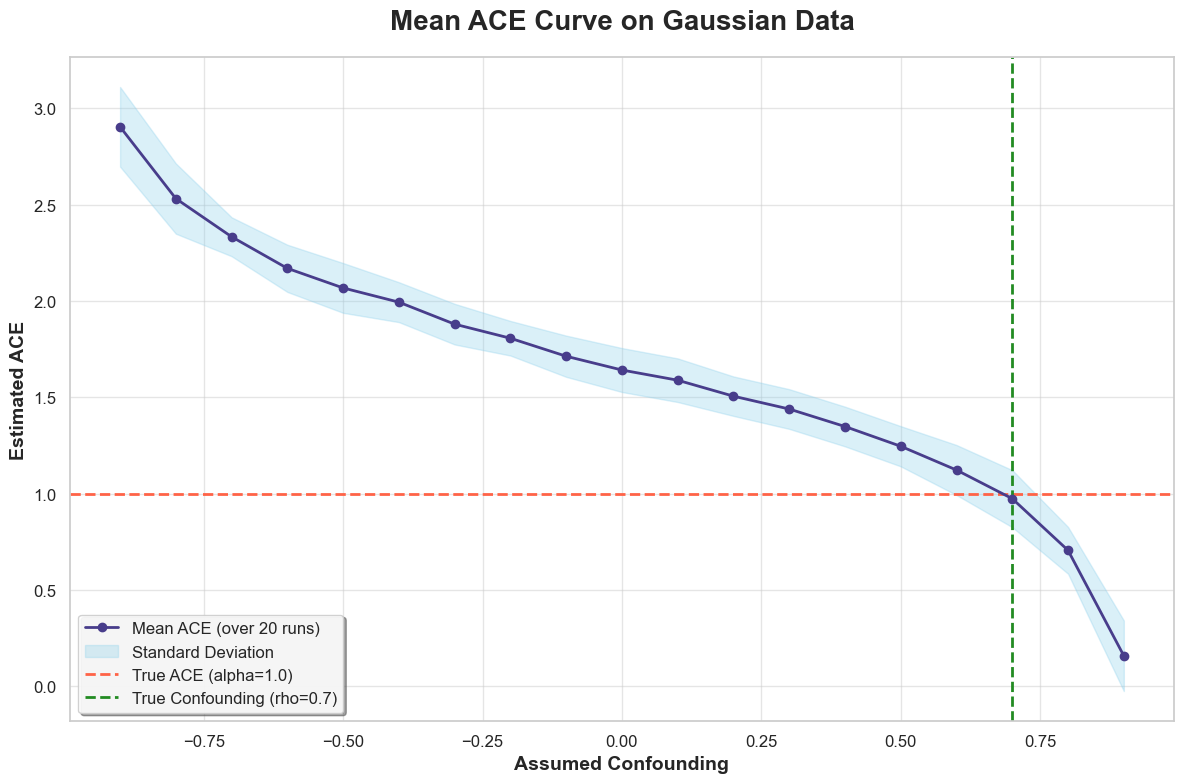

In [ ]:
df = pd.read_csv('df_gaussian_rho.csv')

true_rho_values = sorted(df['true_rho'].unique())
true_alpha = 1.0
number_of_runs = df['run_id'].max()

for rho in true_rho_values:

    subset = df[df['true_rho'] == rho]
    ace_matrix =  subset.pivot(index='run_id', columns='assumed_rho', values='ace_value')
    ace_means = ace_matrix.mean(axis=0).to_numpy()  # Mean ACE for each rho_assumption
    ace_stds = ace_matrix.std(axis=0).to_numpy()    # Std Dev of ACE for each rho_assumption

    plot_mean_std_ace_curve(rho_assumptions = rho_assumptions.numpy(),
                            ace_means = ace_means,
                            ace_stds = ace_stds,
                            true_alpha = true_alpha,
                            true_rho = rho,
                            num_runs = number_of_runs +1,
                            title = f"Mean ACE Curve on Gaussian Data")

## Non-Gaussian (Quadratic)

In [ ]:
# Data generation for non-Gaussian noise
true_alpha = 1.0
non_linear_strength = 0.5
rho_assumptions = torch.linspace(-0.9, 0.9, 19)
T_data_nongauss1, Y_data_nongauss1 = generate_non_gaussian_data(
    num_samples=1000,
    alpha=true_alpha,
    non_linear_strength=non_linear_strength # It is a coefficient to control the strength of the non-linear (U-shaped) dependency between noise terms
)


In [ ]:
# Sensitivity Analysis for non-Gaussian noise
nongauss_ace_results  = sensitivity_analysis(T_data = T_data_nongauss1,
                                            Y_data = Y_data_nongauss1,
                                            learning_rate=3e-3,
                                            steps=1000,
                                            num_ace_samples=100000,
                                            rho_assumptions = rho_assumptions)


===== Training model for rho_assumption = -0.90 =====
Step 0 : loss = 18.708560943603516
--> For rho_assumption=-0.90, Estimated ACE: 2.1273

===== Training model for rho_assumption = -0.80 =====
Step 0 : loss = 11.314919471740723
--> For rho_assumption=-0.80, Estimated ACE: 2.0743

===== Training model for rho_assumption = -0.70 =====
Step 0 : loss = 8.928426742553711
--> For rho_assumption=-0.70, Estimated ACE: 1.9687

===== Training model for rho_assumption = -0.60 =====
Step 0 : loss = 7.770907402038574
--> For rho_assumption=-0.60, Estimated ACE: 1.8715

===== Training model for rho_assumption = -0.50 =====
Step 0 : loss = 7.096485137939453
--> For rho_assumption=-0.50, Estimated ACE: 1.8049

===== Training model for rho_assumption = -0.40 =====
Step 0 : loss = 6.659677505493164
--> For rho_assumption=-0.40, Estimated ACE: 1.6848

===== Training model for rho_assumption = -0.30 =====
Step 0 : loss = 6.356724739074707
--> For rho_assumption=-0.30, Estimated ACE: 1.6302

===== Trai

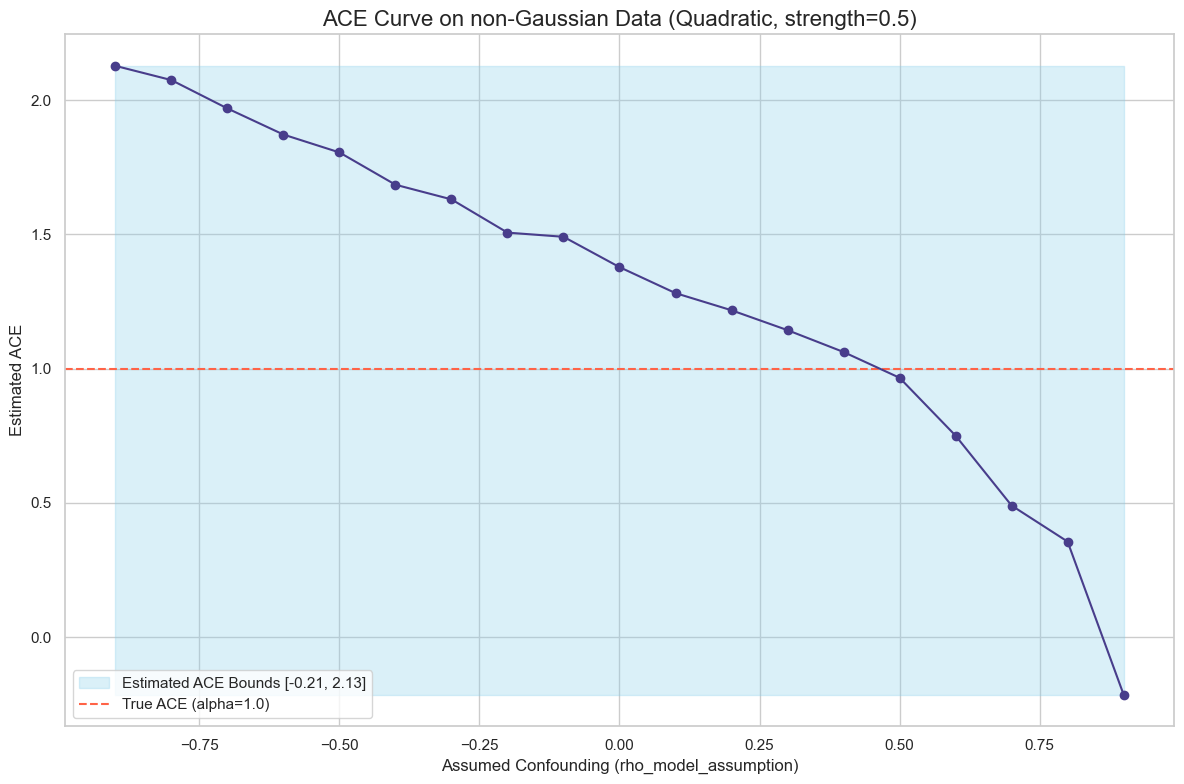

In [ ]:
# Plotting the ACE curve for non-Gaussian noise
plot_ace_curve(
    rho_assumptions = rho_assumptions,
    ace_results = nongauss_ace_results ,
    true_alpha = true_alpha,
    title = "ACE Curve on non-Gaussian Data (Quadratic, strength=0.5)")

### Experiment 1: Testing different true_alpha values for non-Gaussian(Quadratic)

In [ ]:
# Data generation for non-Gaussian noise
number_of_runs = 20
true_alpha_values = [-2.0, 1.0, 2.0]
non_linear_strength = 0.5
rho_assumptions = torch.linspace(-0.9, 0.9, 19)
all_results_nongaussian_alpha = []

for i in range(number_of_runs):
    print(f"\n\n===== RUN {i+1} / {number_of_runs} =====")
    for true_alpha in true_alpha_values:
        T_data_nongauss1, Y_data_nongauss1 = generate_non_gaussian_data(
        num_samples=1000,
        alpha=true_alpha,
        non_linear_strength=non_linear_strength # It is a coefficient to control the strength of the non-linear (U-shaped) dependency between noise terms
    )

    # Sensitivity Analysis for non-Gaussian noise
        nongauss_ace_results  = sensitivity_analysis(T_data = T_data_nongauss1,
                                                    Y_data = Y_data_nongauss1,
                                                    learning_rate=3e-3,
                                                    steps=1000,
                                                    num_ace_samples=100000,
                                                    rho_assumptions = rho_assumptions)
        current_ace_values = nongauss_ace_results if isinstance(nongauss_ace_results, list) else nongauss_ace_results.tolist()
        rho_vals = rho_assumptions.tolist()

        for idx, val in enumerate(current_ace_values):
            all_results_nongaussian_alpha.append({
                'run_id': i,
                'true_alpha': true_alpha,
                'non_linear_strength': non_linear_strength,
                'assumed_rho': rho_vals[idx],
                'ace_value': val
            })

# Dataframe for non-Gaussian (Different alpha values)
df_nongaussian_alpha = pd.DataFrame(all_results_nongaussian_alpha)
df_nongaussian_alpha.to_csv('df_nongaussian_alpha.csv', index=False)



===== RUN 1 / 20 =====

===== Training model for rho_assumption = -0.90 =====
Step 0 : loss = 36.94279861450195
--> For rho_assumption=-0.90, Estimated ACE: -0.0121

===== Training model for rho_assumption = -0.80 =====
Step 0 : loss = 11.237027168273926
--> For rho_assumption=-0.80, Estimated ACE: -0.3687

===== Training model for rho_assumption = -0.70 =====
Step 0 : loss = 38.783607482910156
--> For rho_assumption=-0.70, Estimated ACE: -0.7166

===== Training model for rho_assumption = -0.60 =====
Step 0 : loss = 13.715481758117676
--> For rho_assumption=-0.60, Estimated ACE: -0.8194

===== Training model for rho_assumption = -0.50 =====
Step 0 : loss = 64.96622467041016
--> For rho_assumption=-0.50, Estimated ACE: -0.9957

===== Training model for rho_assumption = -0.40 =====
Step 0 : loss = 13.911417007446289
--> For rho_assumption=-0.40, Estimated ACE: -1.0501

===== Training model for rho_assumption = -0.30 =====
Step 0 : loss = 10.401599884033203
--> For rho_assumption=-0.30,

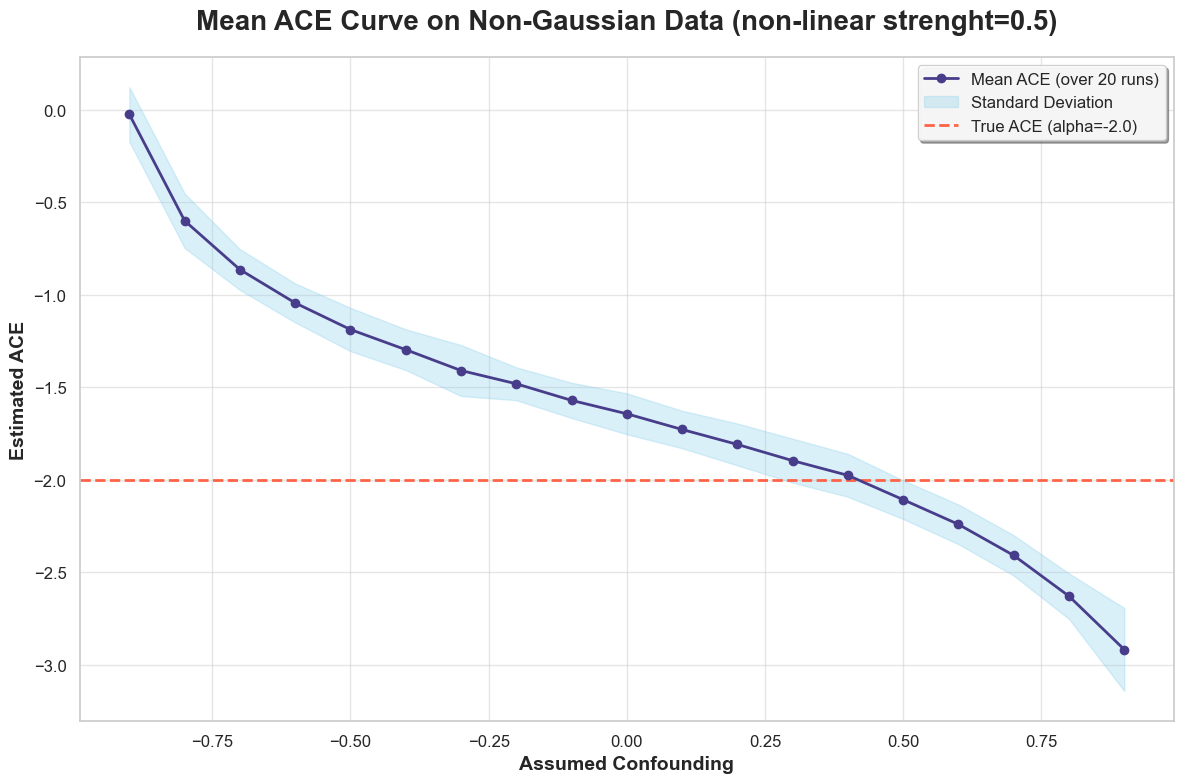

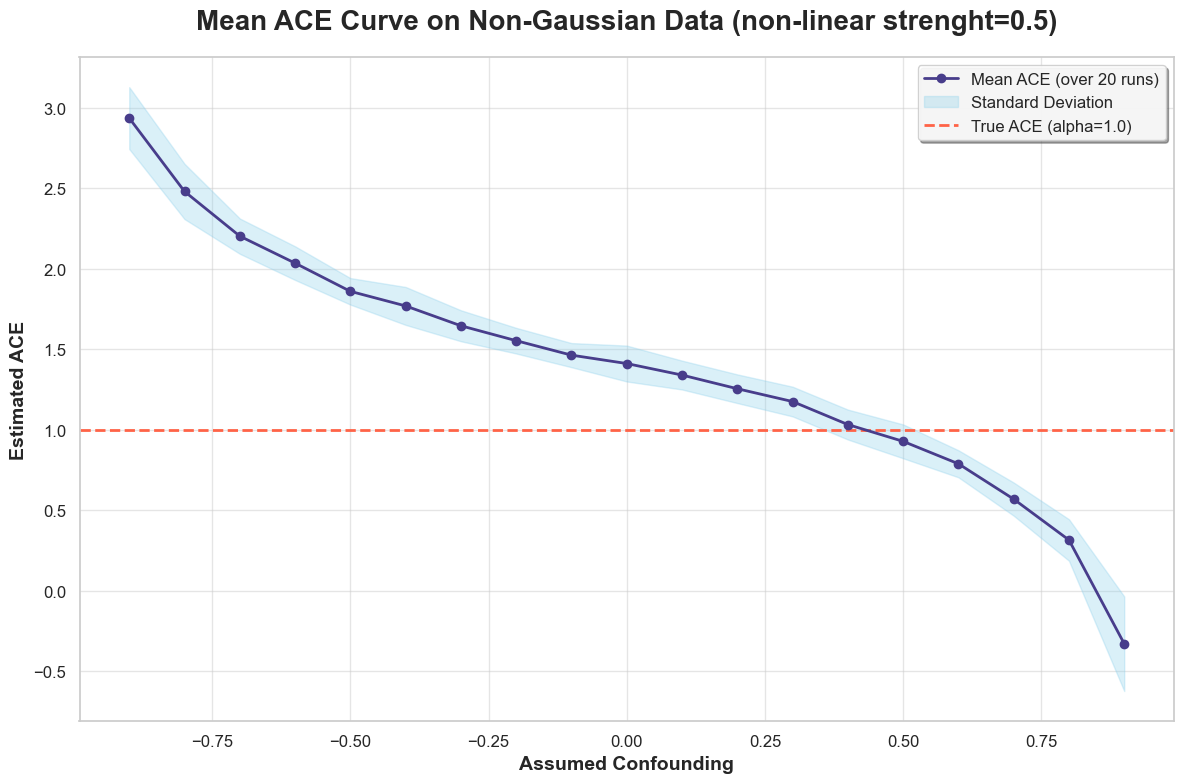

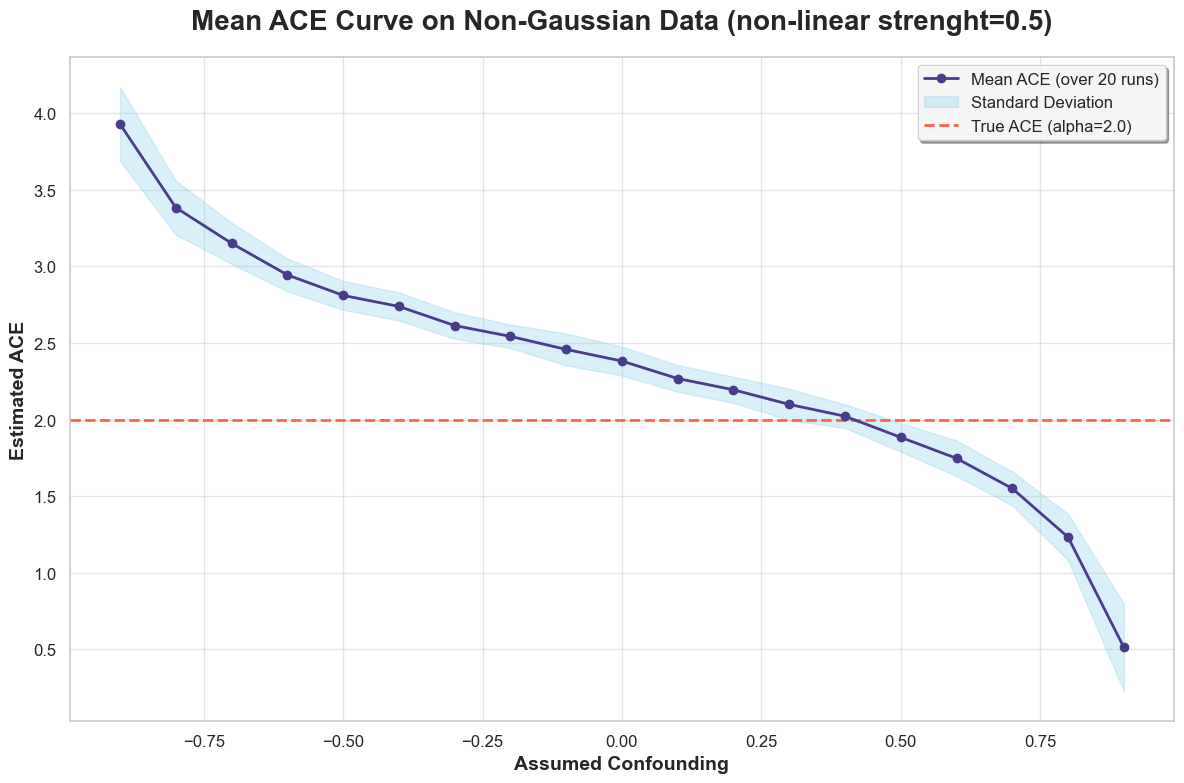

In [ ]:
df = pd.read_csv('df_nongaussian_alpha.csv')

true_alpha_values = sorted(df['true_alpha'].unique())
non_linear_strength = 0.5
number_of_runs = df['run_id'].max()

for alpha in true_alpha_values:

    subdf = df[df['true_alpha'] == alpha]
    ace_matrix = subdf.pivot(index='run_id', columns='assumed_rho', values='ace_value')
    ace_means = ace_matrix.mean(axis=0).to_numpy()  # Mean ACE for each rho_assumption
    ace_stds = ace_matrix.std(axis=0).to_numpy()    # Std Dev of ACE for each rho_assumption

    plot_mean_std_ace_curve(rho_assumptions = rho_assumptions.numpy(),
                            ace_means = ace_means,
                            ace_stds = ace_stds,
                            true_alpha = alpha,
                            num_runs = number_of_runs + 1,
                            title = f"Mean ACE Curve on Non-Gaussian Data (non-linear strenght={non_linear_strength})")

### Experiment 2: Testing different non_linear_strength values for non-Gaussian(Quadratic)

In [ ]:
# Data generation for non-Gaussian noise
number_of_runs = 20
true_alpha = 1
non_linear_strength_values = [-0.5, 0, 0.5]
rho_assumptions = torch.linspace(-0.9, 0.9, 19)
all_results_nongaussian_nonlinear_strength = []

for i in range(number_of_runs):
    print(f"\n\n===== RUN {i+1} / {number_of_runs} =====")
    for non_linear_strength in non_linear_strength_values:
        T_data_nongauss1, Y_data_nongauss1 = generate_non_gaussian_data(
            num_samples=1000,
            alpha=true_alpha,
            non_linear_strength=non_linear_strength # It is a coefficient to control the strength of the non-linear (U-shaped) dependency between noise terms
    )

    # Sensitivity Analysis for non-Gaussian noise
        nongauss_ace_results  = sensitivity_analysis(T_data = T_data_nongauss1,
                                                     Y_data = Y_data_nongauss1,
                                                     learning_rate=3e-3,
                                                     steps=1000,
                                                     num_ace_samples=100000,
                                                     rho_assumptions = rho_assumptions)
        current_ace_values = nongauss_ace_results if isinstance(nongauss_ace_results, list) else nongauss_ace_results.tolist()
        rho_vals = rho_assumptions.tolist()

        for idx, val in enumerate(current_ace_values):
            all_results_nongaussian_nonlinear_strength.append({
                'run_id': i,
                'true_alpha': true_alpha,
                'non_linear_strength': non_linear_strength,
                'assumed_rho': rho_vals[idx],
                'ace_value': val
            })

# Dataframe for non-Gaussian (Different non_linear_strength values)
df_nongaussian_nonlinear_strength = pd.DataFrame(all_results_nongaussian_nonlinear_strength)
df_nongaussian_nonlinear_strength.to_csv('df_nongaussian_nonlinear_strength.csv', index=False)



===== RUN 1 / 20 =====

===== Training model for rho_assumption = -0.90 =====
Step 0 : loss = 48.818973541259766
--> For rho_assumption=-0.90, Estimated ACE: 1.8564

===== Training model for rho_assumption = -0.80 =====
Step 0 : loss = 25.723922729492188
--> For rho_assumption=-0.80, Estimated ACE: 1.6370

===== Training model for rho_assumption = -0.70 =====
Step 0 : loss = 12.453617095947266
--> For rho_assumption=-0.70, Estimated ACE: 1.4944

===== Training model for rho_assumption = -0.60 =====
Step 0 : loss = 17.585527420043945
--> For rho_assumption=-0.60, Estimated ACE: 1.2547

===== Training model for rho_assumption = -0.50 =====
Step 0 : loss = 50.00005340576172
--> For rho_assumption=-0.50, Estimated ACE: 1.0843

===== Training model for rho_assumption = -0.40 =====
Step 0 : loss = 7.1034836769104
--> For rho_assumption=-0.40, Estimated ACE: 1.0230

===== Training model for rho_assumption = -0.30 =====
Step 0 : loss = 33.6630744934082
--> For rho_assumption=-0.30, Estimated

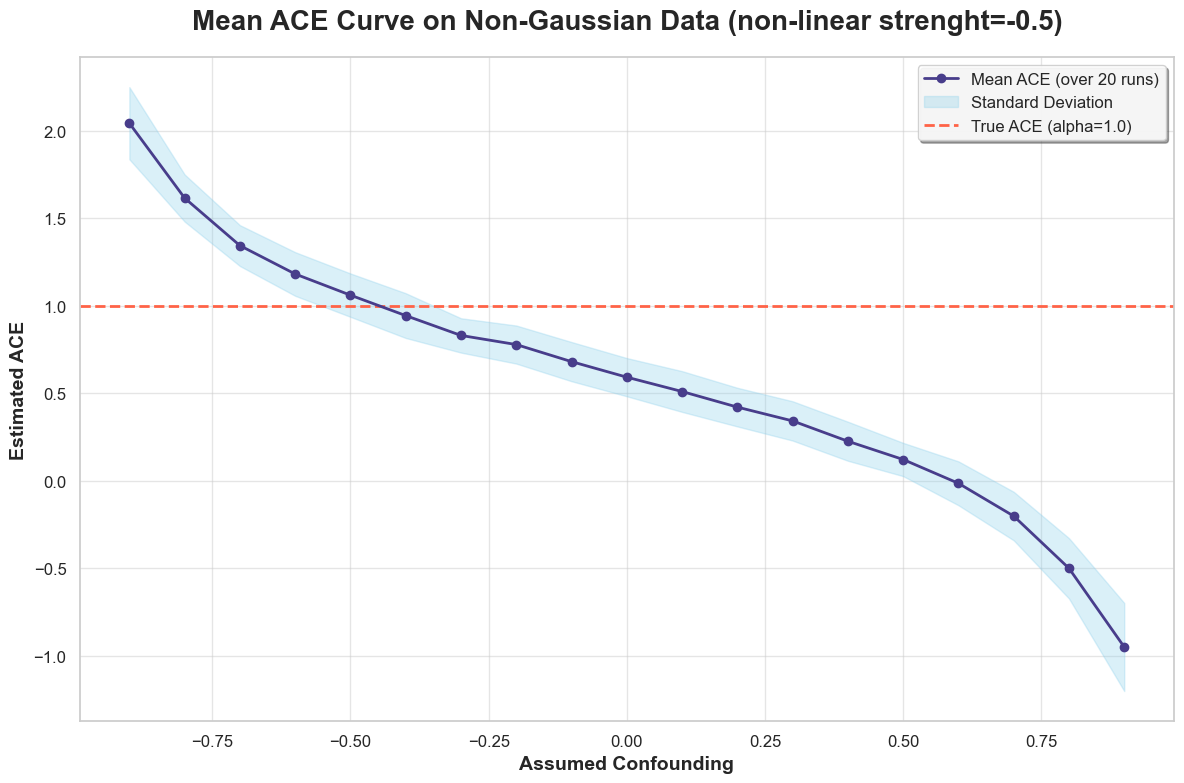

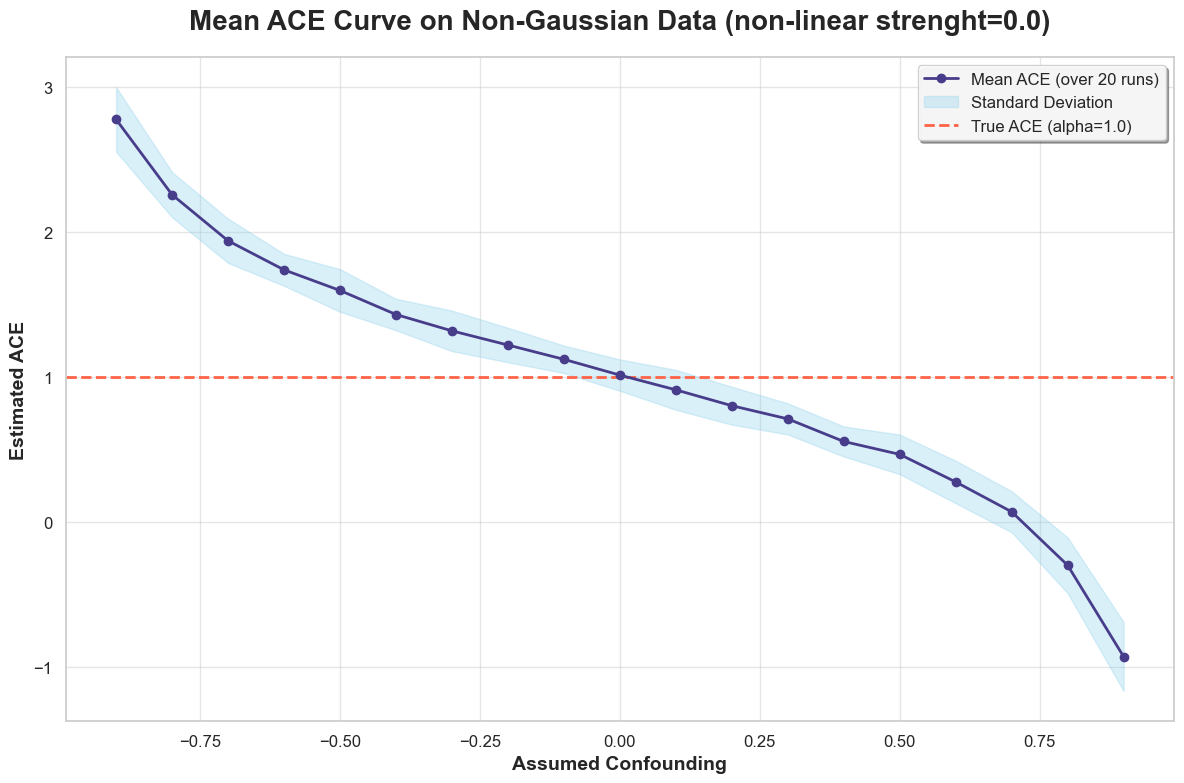

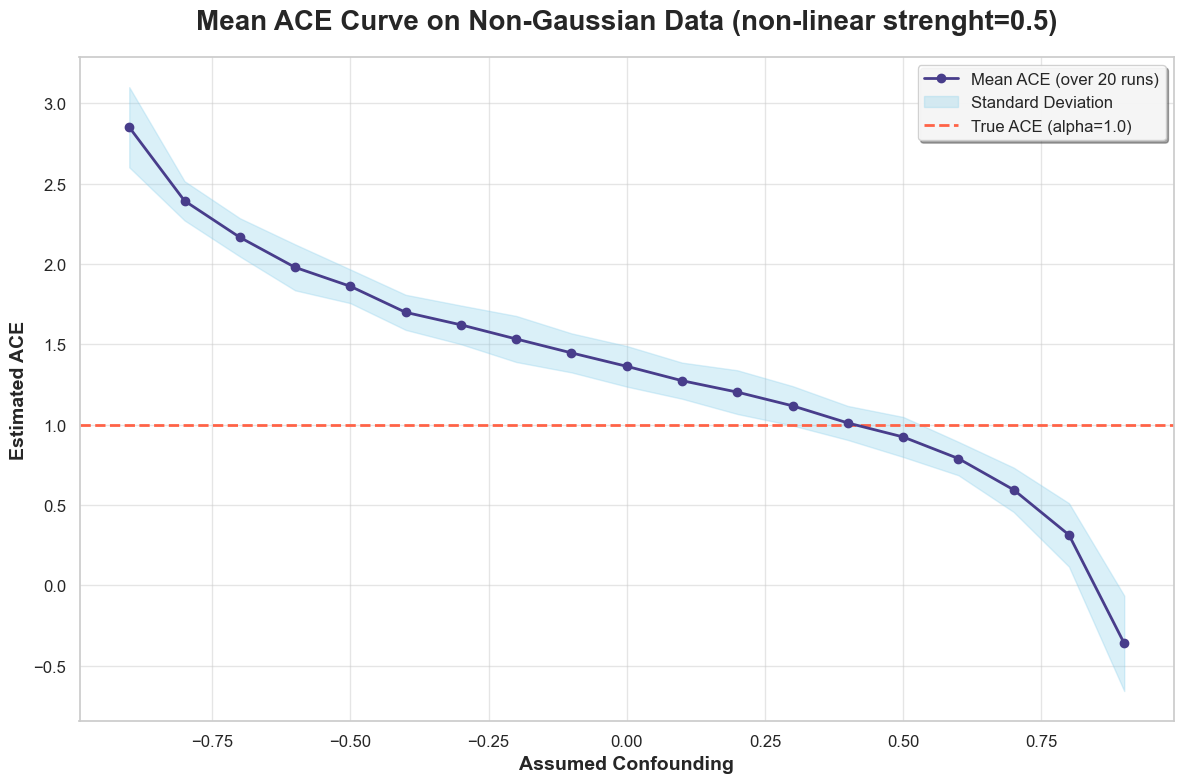

In [ ]:
df = pd.read_csv('df_nongaussian_nonlinear_strength.csv')

non_linear_strength_values = sorted(df['non_linear_strength'].unique())
true_alpha = 1.0
number_of_runs = df['run_id'].max()

for non_linear_strength in non_linear_strength_values:

    subdf = df[df['non_linear_strength'] == non_linear_strength]
    ace_matrix = subdf.pivot(index='run_id', columns='assumed_rho', values='ace_value')
    ace_means = ace_matrix.mean(axis=0).to_numpy()  # Mean ACE for each rho_assumption
    ace_stds = ace_matrix.std(axis=0).to_numpy()    # Std Dev of ACE for each rho_assumption

    plot_mean_std_ace_curve(rho_assumptions = rho_assumptions.numpy(),
                            ace_means = ace_means,
                            ace_stds = ace_stds,
                            true_alpha = true_alpha,
                            num_runs = number_of_runs + 1,
                            title = f"Mean ACE Curve on Non-Gaussian Data (non-linear strenght={non_linear_strength})")

## Clayton (Archimedean) Copula

In [ ]:
# Data generation for Clayton (Archimedean) copula noise
true_alpha = 1.0
theta = 2.0
rho_assumptions = torch.linspace(-0.9, 0.9, 19)
T_data_arch, Y_data_arch = generate_archimedean_data(num_samples=1000,
                                                     alpha=true_alpha,
                                                     theta=theta)

In [ ]:
# Sensitivity Analysis for Archimedean (Clayton) copula noise
arch_ace_results = sensitivity_analysis(T_data = T_data_arch,
                                        Y_data = Y_data_arch,
                                        rho_assumptions = rho_assumptions,
                                        learning_rate = 3e-3,
                                        steps = 1001,
                                        num_ace_samples = 100000)


===== Training model for rho_assumption = -0.90 =====
Step 0 : loss = 23.843137741088867
Step 1000 : loss = 8.446704864501953
--> For rho_assumption=-0.90, Estimated ACE: 1.4559

===== Training model for rho_assumption = -0.80 =====
Step 0 : loss = 13.968893051147461
Step 1000 : loss = 5.704578876495361
--> For rho_assumption=-0.80, Estimated ACE: 1.6584

===== Training model for rho_assumption = -0.70 =====
Step 0 : loss = 10.758846282958984
Step 1000 : loss = 4.690459251403809
--> For rho_assumption=-0.70, Estimated ACE: 1.7662

===== Training model for rho_assumption = -0.60 =====
Step 0 : loss = 9.192501068115234
Step 1000 : loss = 4.132209300994873
--> For rho_assumption=-0.60, Estimated ACE: 1.7402

===== Training model for rho_assumption = -0.50 =====
Step 0 : loss = 8.275616645812988
Step 1000 : loss = 3.8035192489624023
--> For rho_assumption=-0.50, Estimated ACE: 1.7176

===== Training model for rho_assumption = -0.40 =====
Step 0 : loss = 7.680033206939697
Step 1000 : loss 

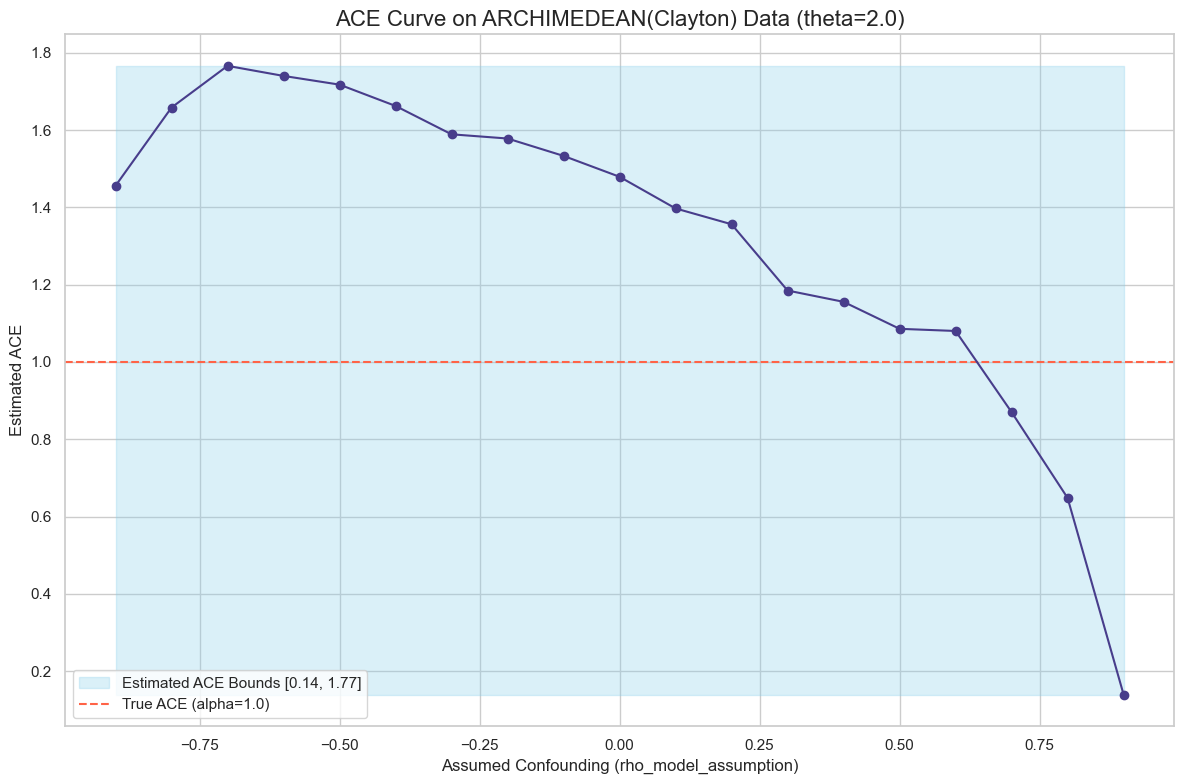

In [ ]:
# Plotting the ACE curve for Archimedean (Clayton) copula noise
plot_ace_curve(
    rho_assumptions = rho_assumptions,
    ace_results = arch_ace_results,
    true_alpha = true_alpha,
    title = "ACE Curve on ARCHIMEDEAN(Clayton) Data (theta=2.0)"
)

### Experiment 1: Testing different true_alpha values for Clayton (Archimedean)

In [ ]:
# Data generation for Clayton (Archimedean) copula noise
number_of_runs = 20
true_alpha_values = [-2.0, 1.0, 2.0]
theta = 2
rho_assumptions = torch.linspace(-0.9, 0.9, 19)
all_results_clayton_alpha = []

for i in range(number_of_runs):
    print(f"\n\n===== RUN {i+1} / {number_of_runs} =====")
    for true_alpha in true_alpha_values:
        T_data_arch, Y_data_arch = generate_archimedean_data(num_samples=1000,
                                                            alpha=true_alpha,
                                                            theta=theta)

        # Sensitivity Analysis for Archimedean (Clayton) copula noise
        arch_ace_results = sensitivity_analysis(T_data = T_data_arch,
                                                Y_data = Y_data_arch,
                                                rho_assumptions = rho_assumptions,
                                                learning_rate = 3e-3,
                                                steps = 1001,
                                                num_ace_samples = 100000)
        current_ace_values = arch_ace_results if isinstance(arch_ace_results, list) else arch_ace_results.tolist()
        rho_vals = rho_assumptions.tolist()

        for idx, val in enumerate(current_ace_values):
            all_results_clayton_alpha.append({
                'run_id': i,
                'true_alpha': true_alpha,
                'theta': theta,
                'assumed_rho': rho_vals[idx],
                'ace_value': val
            })

# Dataframe for Clayton (Different alpha values)
df_clayton_alpha = pd.DataFrame(all_results_clayton_alpha)
df_clayton_alpha.to_csv('df_clayton_alpha.csv', index=False)



===== RUN 1 / 20 =====

===== Training model for rho_assumption = -0.90 =====
Step 0 : loss = 22.221473693847656
Step 1000 : loss = 2.459620952606201
--> For rho_assumption=-0.90, Estimated ACE: 0.4559

===== Training model for rho_assumption = -0.80 =====
Step 0 : loss = 70.09244537353516
Step 1000 : loss = 2.4544224739074707
--> For rho_assumption=-0.80, Estimated ACE: -0.5827

===== Training model for rho_assumption = -0.70 =====
Step 0 : loss = 30.886781692504883
Step 1000 : loss = 2.4520390033721924
--> For rho_assumption=-0.70, Estimated ACE: -0.7290

===== Training model for rho_assumption = -0.60 =====
Step 0 : loss = 4.5222039222717285
Step 1000 : loss = 2.4136345386505127
--> For rho_assumption=-0.60, Estimated ACE: -1.0141

===== Training model for rho_assumption = -0.50 =====
Step 0 : loss = 46.13322830200195
Step 1000 : loss = 2.451709747314453
--> For rho_assumption=-0.50, Estimated ACE: -1.0756

===== Training model for rho_assumption = -0.40 =====
Step 0 : loss = 50.4

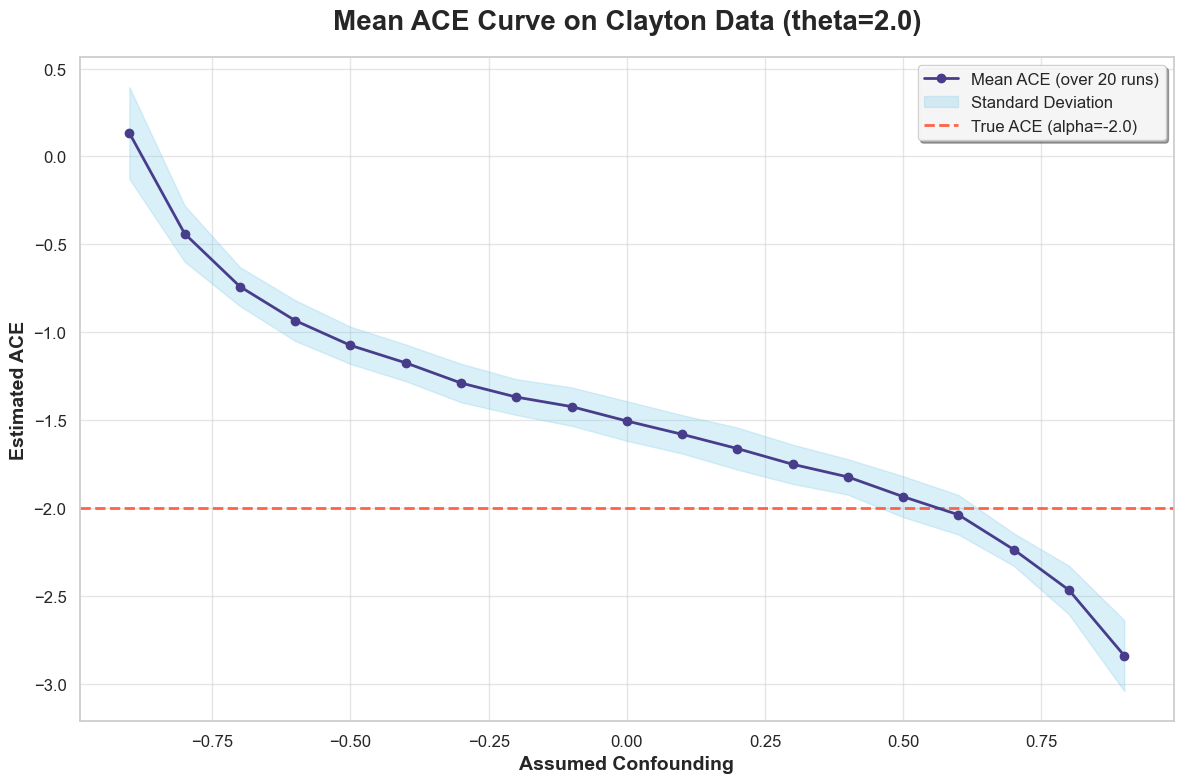

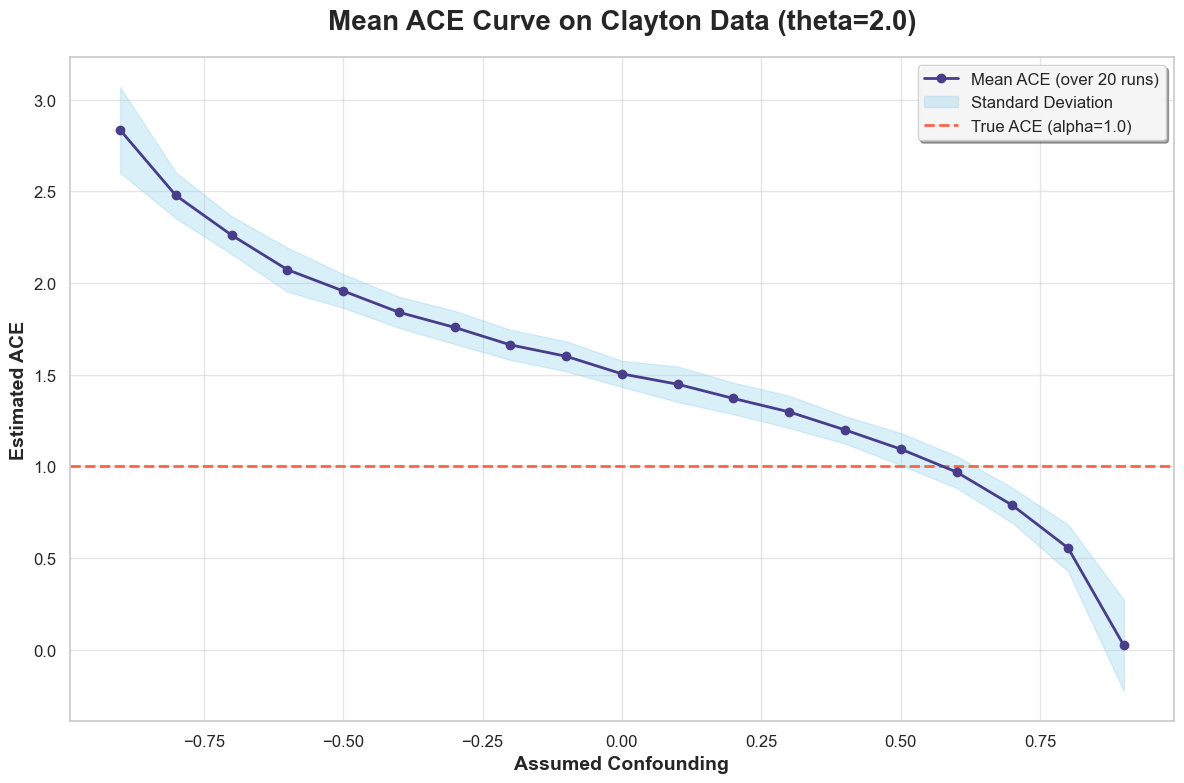

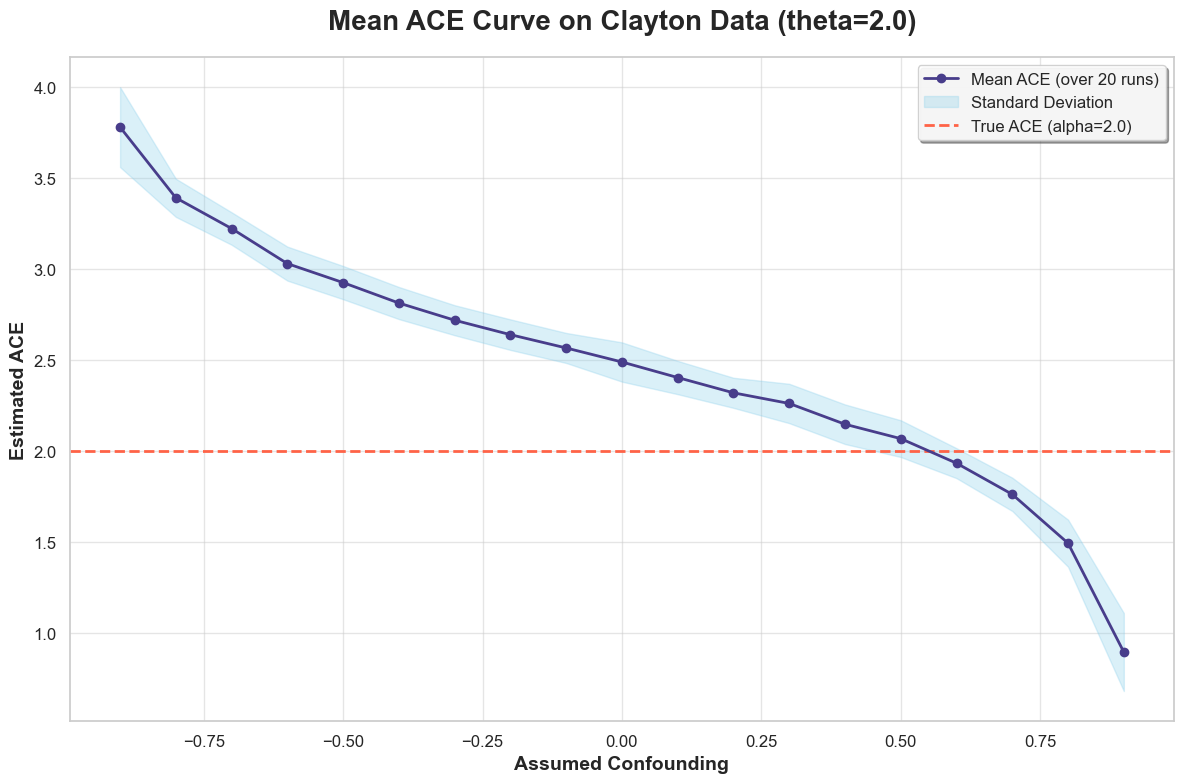

In [ ]:
df = pd.read_csv('df_clayton_alpha.csv')
true_alpha_values = sorted(df['true_alpha'].unique())
theta = 2.0
number_of_runs = df['run_id'].max()

for alpha in true_alpha_values:

    subset = df[df['true_alpha'] == alpha]
    ace_matrix = subset.pivot(index='run_id', columns='assumed_rho', values='ace_value')
    ace_means = ace_matrix.mean(axis=0).to_numpy()  # Mean ACE for each rho_assumption
    ace_stds = ace_matrix.std(axis=0).to_numpy()    # Std Dev of ACE for each rho_assumption

    plot_mean_std_ace_curve(rho_assumptions = rho_assumptions.numpy(),
                            ace_means = ace_means,
                            ace_stds = ace_stds,
                            true_alpha = alpha,
                            num_runs = number_of_runs + 1,
                            title = f"Mean ACE Curve on Clayton Data (theta={theta})")

### Experiment 2: Testing different theta values for Clayton (Archimedean)

In [ ]:
# Data generation for Clayton (Archimedean) copula noise
number_of_runs = 20
true_alpha = 1.0
theta_values = [0.1, 2, 5.0]
rho_assumptions = torch.linspace(-0.9, 0.9, 19)
all_results_clayton_theta = []

for i in range(number_of_runs):
    print(f"\n\n===== RUN {i+1} / {number_of_runs} =====")
    for theta in theta_values:
        T_data_arch, Y_data_arch = generate_archimedean_data(num_samples=1000,
                                                            alpha=true_alpha,
                                                            theta=theta)

        # Sensitivity Analysis for Archimedean (Clayton) copula noise
        arch_ace_results = sensitivity_analysis(T_data = T_data_arch,
                                                Y_data = Y_data_arch,
                                                rho_assumptions = rho_assumptions,
                                                learning_rate = 3e-3,
                                                steps = 1001,
                                                num_ace_samples = 100000)
        current_ace_values = arch_ace_results if isinstance(arch_ace_results, list) else arch_ace_results.tolist()
        rho_vals = rho_assumptions.tolist()

        for idx, val in enumerate(current_ace_values):
            all_results_clayton_theta.append({
                'run_id': i,
                'true_alpha': true_alpha,
                'theta': theta,
                'assumed_rho': rho_vals[idx],
                'ace_value': val
            })

# Dataframe for Clayton (Different theta values)
df_clayton_theta = pd.DataFrame(all_results_clayton_theta)
df_clayton_theta.to_csv('df_clayton_theta.csv', index=False)



===== RUN 1 / 20 =====

===== Training model for rho_assumption = -0.90 =====
Step 0 : loss = 56.065284729003906
Step 1000 : loss = 2.8466739654541016
--> For rho_assumption=-0.90, Estimated ACE: 2.8422

===== Training model for rho_assumption = -0.80 =====
Step 0 : loss = 29.134735107421875
Step 1000 : loss = 2.8448028564453125
--> For rho_assumption=-0.80, Estimated ACE: 2.1991

===== Training model for rho_assumption = -0.70 =====
Step 0 : loss = 7.339227676391602
Step 1000 : loss = 2.8116676807403564
--> For rho_assumption=-0.70, Estimated ACE: 1.9941

===== Training model for rho_assumption = -0.60 =====
Step 0 : loss = 19.11798667907715
Step 1000 : loss = 2.8169138431549072
--> For rho_assumption=-0.60, Estimated ACE: 1.8505

===== Training model for rho_assumption = -0.50 =====
Step 0 : loss = 14.548569679260254
Step 1000 : loss = 2.8399710655212402
--> For rho_assumption=-0.50, Estimated ACE: 1.7327

===== Training model for rho_assumption = -0.40 =====
Step 0 : loss = 46.434

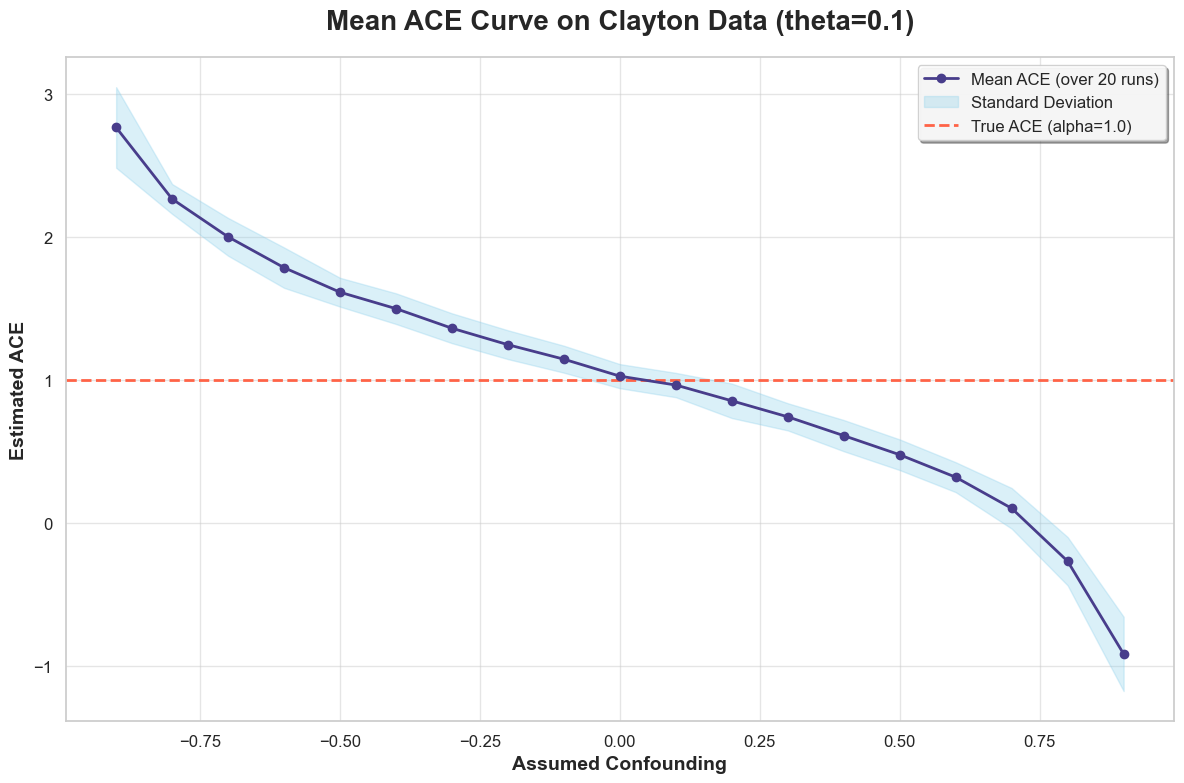

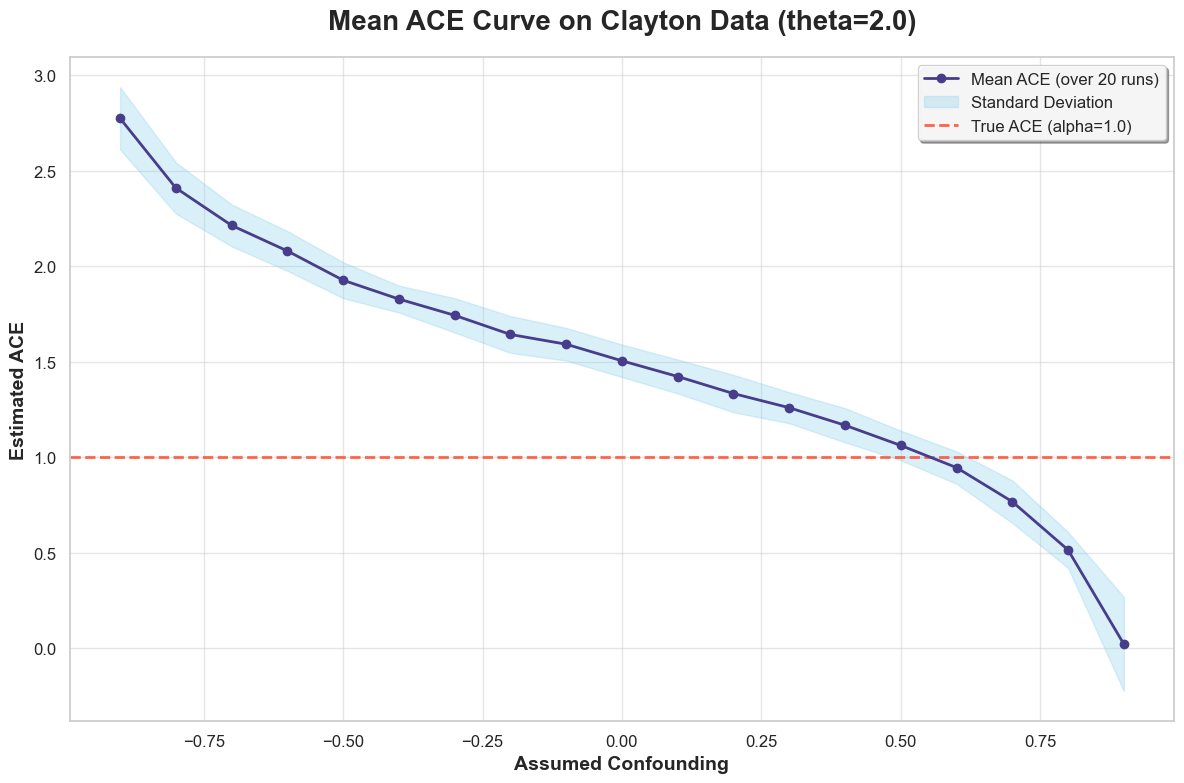

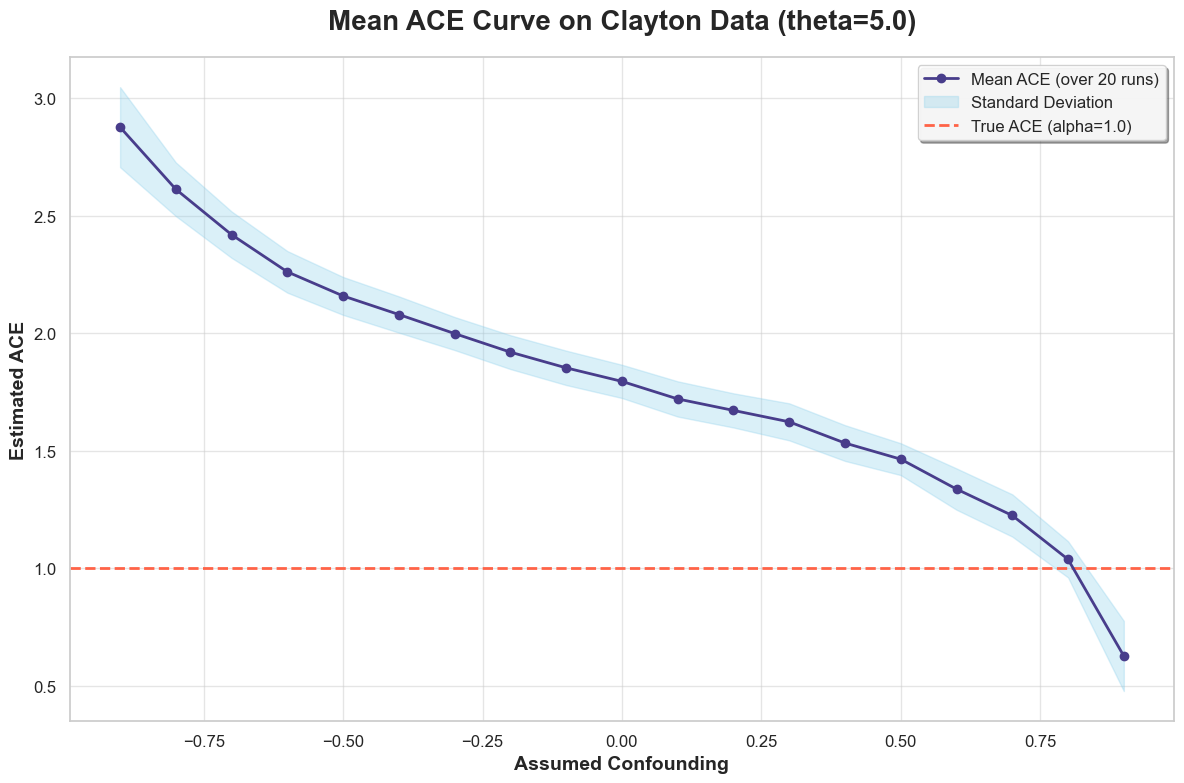

In [ ]:
df = pd.read_csv('df_clayton_theta.csv')
theta_values = sorted(df['theta'].unique())
true_alpha = 1.0
number_of_runs = df['run_id'].max()

for theta in theta_values:

    subset = df[df['theta'] == theta]
    ace_matrix = subset.pivot(index='run_id', columns='assumed_rho', values='ace_value')
    ace_means = ace_matrix.mean(axis=0).to_numpy()  # Mean ACE for each rho_assumption
    ace_stds = ace_matrix.std(axis=0).to_numpy()    # Std Dev of ACE for each rho_assumption

    plot_mean_std_ace_curve(rho_assumptions = rho_assumptions.numpy(),
                            ace_means = ace_means,
                            ace_stds = ace_stds,
                            true_alpha = true_alpha,
                            num_runs = number_of_runs + 1,
                            title = f"Mean ACE Curve on Clayton Data (theta={theta})")